## MARBL diagnostics, compare timeseries of global metrics between multiple cases (only 2-d variables)


In [1]:
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
import os
from glob import glob
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cftime
import pandas as pd
import matplotlib.gridspec as gridspec
from xgcm import Grid
xr.set_options(keep_attrs=True);

### Cases to be compared with major changes

#### All cases are with alpha09d tag

• 003: default POC diss

• 004: 125m POC diss


### Come up with short names for each case

In [2]:
short_names = ['003',
               '004',
              ]

### Define number of years and number of cases

In [5]:
num_cases = len(short_names)
num_years = 86 #max years in any of the runs

### Define cases

In [6]:
sandbox = 'g.e30_a09e.GW1850MARBL_CPLHIST_PHYS_CYCLE.ne30pg3_t233_wg37'

case_nums = ['003','004']

user = 'klindsay'

### Define the year range

In [8]:
start_yr = 1
endyr = start_yr + num_years 

### 2-D variable list

In [9]:
variables2d = ['photoC_TOT_zint','photoC_sp_zint','photoC_diat_zint',
               'photoC_diaz_zint','photoC_cocco_zint','CaCO3_PROD_zint',
               'POC_FLUX_100m','x_graze_microzoo_zint',
               'x_graze_mesozoo_zint','IFRAC','FG_CO2','diat_Fe_lim_surf'] 

variables3d = ['DIC','ALK','PO4','NO3','SiO3'] 

coords = {'x':'yh','y':'xh'}


keepthese=['z_l','z_i','time_bounds','time','average_T1', 'average_T2','average_DT'] + variables3d + list(coords.values())

### Get dask going

In [10]:
def get_ClusterClient():
    import dask
    from dask_jobqueue import PBSCluster
    from dask.distributed import Client
    cluster = PBSCluster(
        cores=2,
        memory='25 GB',
        processes=1,
        queue='casper',
        resource_spec='select=1:ncpus=1:mem=25GB',
        project='NCGD0011',
        walltime='03:00:00',
        interface='ext',
        log_directory='./dask-logs'
    )

    dask.config.set({
        'distributed.dashboard.link':
        'https://jupyterhub.hpc.ucar.edu/stable/user/{USER}/proxy/{port}/status'
    })
    client = Client(cluster)
    return cluster, client

In [11]:
cluster, client = get_ClusterClient()
cluster.scale(12) 
client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kristenk/proxy/45175/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kristenk/proxy/45175/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.174:39865,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kristenk/proxy/45175/status,Total threads: 0
Started: Just now,Total memory: 0 B


### Read in all the data

In [12]:
cases_dict = {}

for case_num in case_nums:
    case = sandbox + '.' + case_num
    print(case)

    files = []
    for year in range(start_yr,endyr):
        yr4="{:04d}".format(year)
        print('doing simulation year', year, '!')
        files.extend(sorted(glob(f'/glade/derecho/scratch/{user}/archive/{case}/ocn/hist/{case}.mom6.h.bgc.z_annual.{yr4}.nc')))
    ds_tmp = xr.open_mfdataset(files,decode_times=True,decode_coords=False, concat_dim='time',combine='nested' )
    ds_tmp = ds_tmp.drop([v for v in ds_tmp.variables if v not in keepthese])
    cases_dict[case_num] = ds_tmp

g.e30_a09e.GW1850MARBL_CPLHIST_PHYS_CYCLE.ne30pg3_t233_wg37.003
doing simulation year 1 !
doing simulation year 2 !
doing simulation year 3 !
doing simulation year 4 !
doing simulation year 5 !
doing simulation year 6 !
doing simulation year 7 !
doing simulation year 8 !
doing simulation year 9 !
doing simulation year 10 !
doing simulation year 11 !
doing simulation year 12 !
doing simulation year 13 !
doing simulation year 14 !
doing simulation year 15 !
doing simulation year 16 !
doing simulation year 17 !
doing simulation year 18 !
doing simulation year 19 !
doing simulation year 20 !
doing simulation year 21 !
doing simulation year 22 !
doing simulation year 23 !
doing simulation year 24 !
doing simulation year 25 !
doing simulation year 26 !
doing simulation year 27 !
doing simulation year 28 !
doing simulation year 29 !
doing simulation year 30 !
doing simulation year 31 !
doing simulation year 32 !
doing simulation year 33 !
doing simulation year 34 !
doing simulation year 35 !


In [13]:
cases_dict.keys()

dict_keys(['003', '004'])

In [14]:
ds_tmp

<xarray.Dataset> Size: 9GB
Dimensions:      (time: 50, z_l: 34, yh: 480, xh: 540, nbnd: 2, z_i: 35)
Coordinates:
  * xh           (xh) float64 4kB -286.7 -286.0 -285.3 ... 71.33 72.0 72.67
  * yh           (yh) float64 4kB -81.56 -81.46 -81.36 ... 87.65 87.71 87.74
  * z_l          (z_l) float64 272B 2.5 10.0 20.0 32.5 ... 5e+03 5.5e+03 6e+03
  * z_i          (z_i) float64 280B 0.0 5.0 15.0 ... 5.25e+03 5.75e+03 6.25e+03
  * time         (time) object 400B 0037-07-02 12:00:00 ... 0086-07-02 12:00:00
Dimensions without coordinates: nbnd
Data variables:
    ALK          (time, z_l, yh, xh) float32 2GB dask.array<chunksize=(1, 34, 480, 540), meta=np.ndarray>
    DIC          (time, z_l, yh, xh) float32 2GB dask.array<chunksize=(1, 34, 480, 540), meta=np.ndarray>
    NO3          (time, z_l, yh, xh) float32 2GB dask.array<chunksize=(1, 34, 480, 540), meta=np.ndarray>
    PO4          (time, z_l, yh, xh) float32 2GB dask.array<chunksize=(1, 34, 480, 540), meta=np.ndarray>
    SiO3         (time, z_l, yh, xh) float32 2GB dask.array<chunksize=(1, 34, 480, 540), meta=np.ndarray>
    average_T1   (time) object 400B dask.array<chunksize=(1,), meta=np.ndarray>
    average_T2   (time) object 400B dask.array<chunksize=(1,), meta=np.ndarray>
    average_DT   (time) timedelta64[ns] 400B dask.array<chunksize=(1,), meta=np.ndarray>
    time_bounds  (time, nbnd) object 800B dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes:
    NumFilesInSet:     1
    title:             MOM6 diagnostic fields table for CESM case: g.e30_a09e...
    associated_files:  areacello: g.e30_a09e.GW1850MARBL_CPLHIST_PHYS_CYCLE.n...
    grid_type:         regular
    grid_tile:         N/A

## Get the grid data for MOM6

In [15]:
ds_grid = xr.open_dataset(f'/glade/work/kristenk/cesm_work/mom6_static_files/g.e23b16.TL319_t232.GIAFMARBL.001.mom6.h.static.nc')

In [16]:
lons = ds_grid.geolon
lats = ds_grid.geolat
area = ds_grid.areacello #m2

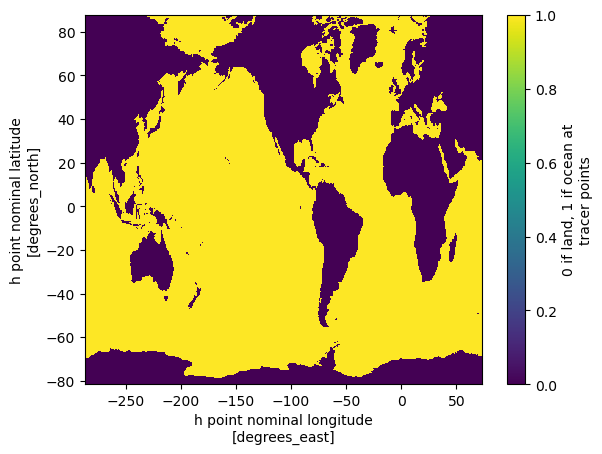

In [17]:
ds_grid.wet.plot()

### make a mean over the last 10 yrs of each model run

In [18]:
mean_case_dict = {}

for case in cases_dict.keys():
    print(case)

    mean_case_dict[case] = cases_dict[case].isel(time=slice(-10, None)).mean(dim="time")

003
004


In [19]:
mean_case_dict.keys()

dict_keys(['003', '004'])

### Make some difference maps

In [23]:
ds_diff = mean_case_dict['004'] - mean_case_dict['003']

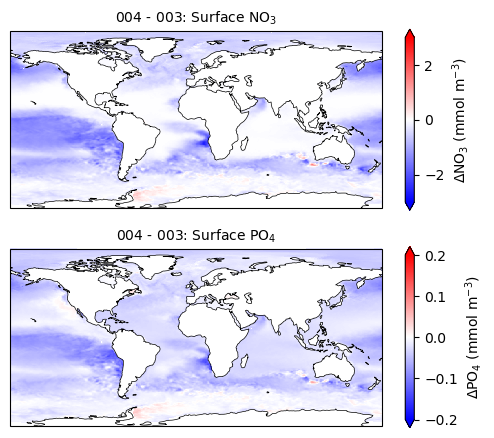

In [36]:
fig = plt.figure(figsize=(6,8))

####################NO3
ax = fig.add_subplot(3,1,1, projection=ccrs.PlateCarree())
#ax.set_extent([-180, 180, -90, 90], ccrs.PlateCarree())
ax.coastlines('110m',linewidth=0.5)
ax.set_title('004 - 003: Surface NO$_3$', fontsize=10)
pc1=ax.pcolormesh(lons, lats, ds_diff.NO3.isel(z_l=0), 
                  vmin=-3, vmax=3, cmap='bwr',
                  transform=ccrs.PlateCarree())
cbar1 = fig.colorbar(pc1, ax=ax,extend='both',label='${\Delta}$NO$_3$ (mmol m$^{-3}$)')

####################PO4
ax = fig.add_subplot(3,1,2, projection=ccrs.PlateCarree())
#ax.set_extent([-180, 180, -90, 90], ccrs.PlateCarree())
ax.coastlines('110m',linewidth=0.5)
ax.set_title('004 - 003: Surface PO$_4$', fontsize=10)
pc1=ax.pcolormesh(lons, lats, ds_diff.PO4.isel(z_l=0), 
                  vmin=-0.2, vmax=0.2, cmap='bwr',
                  transform=ccrs.PlateCarree())
cbar1 = fig.colorbar(pc1, ax=ax,extend='both',label='${\Delta}$PO$_4$ (mmol m$^{-3}$)')


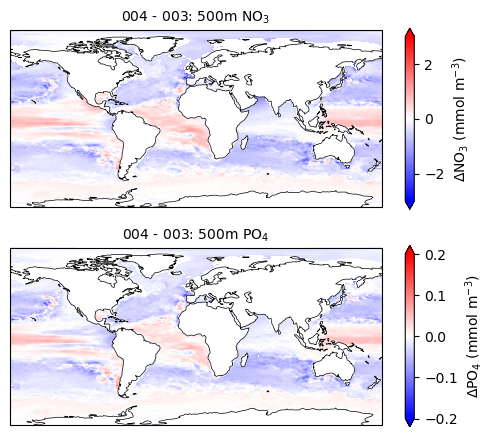

In [37]:
fig = plt.figure(figsize=(6,8))

####################NO3
ax = fig.add_subplot(3,1,1, projection=ccrs.PlateCarree())
#ax.set_extent([-180, 180, -90, 90], ccrs.PlateCarree())
ax.coastlines('110m',linewidth=0.5)
ax.set_title('004 - 003: 500m NO$_3$', fontsize=10)
pc1=ax.pcolormesh(lons, lats, ds_diff.NO3.isel(z_l=13), 
                  vmin=-3, vmax=3, cmap='bwr',
                  transform=ccrs.PlateCarree())
cbar1 = fig.colorbar(pc1, ax=ax,extend='both',label='${\Delta}$NO$_3$ (mmol m$^{-3}$)')

####################PO4
ax = fig.add_subplot(3,1,2, projection=ccrs.PlateCarree())
#ax.set_extent([-180, 180, -90, 90], ccrs.PlateCarree())
ax.coastlines('110m',linewidth=0.5)
ax.set_title('004 - 003: 500m PO$_4$', fontsize=10)
pc1=ax.pcolormesh(lons, lats, ds_diff.PO4.isel(z_l=13), 
                  vmin=-0.2, vmax=0.2, cmap='bwr',
                  transform=ccrs.PlateCarree())
cbar1 = fig.colorbar(pc1, ax=ax,extend='both',label='${\Delta}$PO$_4$ (mmol m$^{-3}$)')


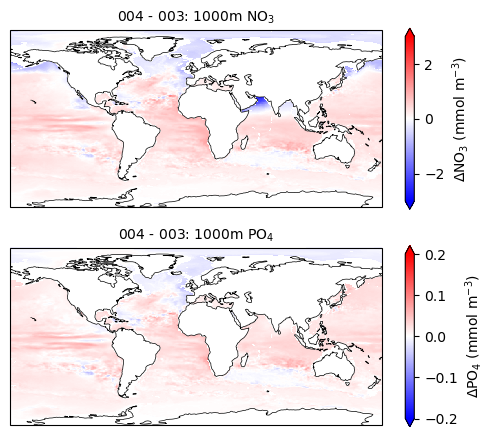

In [40]:
fig = plt.figure(figsize=(6,8))

####################NO3
ax = fig.add_subplot(3,1,1, projection=ccrs.PlateCarree())
#ax.set_extent([-180, 180, -90, 90], ccrs.PlateCarree())
ax.coastlines('110m',linewidth=0.5)
ax.set_title('004 - 003: 1000m NO$_3$', fontsize=10)
pc1=ax.pcolormesh(lons, lats, ds_diff.NO3.isel(z_l=18), 
                  vmin=-3, vmax=3, cmap='bwr',
                  transform=ccrs.PlateCarree())
cbar1 = fig.colorbar(pc1, ax=ax,extend='both',label='${\Delta}$NO$_3$ (mmol m$^{-3}$)')

####################PO4
ax = fig.add_subplot(3,1,2, projection=ccrs.PlateCarree())
#ax.set_extent([-180, 180, -90, 90], ccrs.PlateCarree())
ax.coastlines('110m',linewidth=0.5)
ax.set_title('004 - 003: 1000m PO$_4$', fontsize=10)
pc1=ax.pcolormesh(lons, lats, ds_diff.PO4.isel(z_l=18), 
                  vmin=-0.2, vmax=0.2, cmap='bwr',
                  transform=ccrs.PlateCarree())
cbar1 = fig.colorbar(pc1, ax=ax,extend='both',label='${\Delta}$PO$_4$ (mmol m$^{-3}$)')
